# Phase 1 to Phase 3 Success Prediction for Alzheimer's Disease

## Project Goal

**Objective**: Predict which Alzheimer's Disease drugs that appear in Phase 1 trials will successfully progress to Phase 3 trials.

**Success Definition**: A Phase 1 drug is considered successful if it progresses through Phase 1 → Phase 2 → Phase 3 (i.e., there exists a Phase 3 trial for the same intervention).

**Key Constraint**: Only use information available at Phase 1 timepoint (no data leakage from future phases).

## Notebook Structure

1. **Data Fetching**: Fetch Phase 1 and Phase 3 Alzheimer trials
2. **Label Creation**: Match Phase 1 interventions to Phase 3 trials to create success labels
3. **Feature Engineering**: Extract Phase 1 features (design, drug attributes, sponsor, etc.)
4. **Data Exploration**: Analyze feature distributions, label balance, feature importance
5. **Modeling**: Train models to predict Phase 1 → Phase 3 success
6. **Evaluation**: Assess model performance using PR AUC, ROC AUC, Accuracy, Precision

## Metrics

- **PR AUC** (Precision-Recall AUC): Important for imbalanced datasets
- **ROC AUC**: Overall discriminative ability
- **Accuracy**: Overall correctness
- **Precision**: Of predicted successes, how many are actually successful


## 1. Setup and Imports


In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path
import sys
import warnings
import requests
import time
import os
from typing import List, Dict, Any, Tuple
from datetime import datetime
import re
from collections import Counter
warnings.filterwarnings('ignore')

# Machine learning imports
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score, accuracy_score, precision_score,
    recall_score, f1_score, confusion_matrix, roc_curve, precision_recall_curve
)
import xgboost as xgb

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Set paths
BASE_DIR = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_DIR = BASE_DIR / 'data'
RAW_DATA_DIR = DATA_DIR / 'raw'
PROCESSED_DATA_DIR = DATA_DIR / 'processed'

# Create directories if they don't exist
RAW_DATA_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

print(f"Base directory: {BASE_DIR}")
print(f"Data directory: {DATA_DIR}")


Base directory: /Users/yifei/Documents/Duke/AIPI 520/Code/Projects/proj_2/clinical-trial-success-predictor/yifei
Data directory: /Users/yifei/Documents/Duke/AIPI 520/Code/Projects/proj_2/clinical-trial-success-predictor/yifei/data


## 2. Data Fetching

### 2.1 Fetch Phase 1 Trials

We need to fetch all Phase 1 Alzheimer's Disease trials to use as our base dataset.


In [2]:
# ============================================================================
# DATA FETCHING CONFIGURATION
# ============================================================================

# Set fetch_from_api = True to fetch new data, False to use existing saved data
FETCH_FROM_API = True  # Change to False if you want to use existing saved data

# Set FETCH_ALL = True to automatically get all studies
FETCH_ALL = True  # Set to True to fetch all available studies

# Maximum pages (ignored if FETCH_ALL=True)
MAX_PAGES = 500
PAGE_SIZE = 100  # Maximum allowed by API

# ============================================================================
# API FETCHING FUNCTION
# ============================================================================

BASE_URL = "https://clinicaltrials.gov/api/v2/studies"

def fetch_alzheimer_trials_by_phase(
    phase_filter: str = "PHASE1",
    max_pages: int = 10,
    page_size: int = 100,
    fetch_all: bool = False
) -> List[Dict[str, Any]]:
    """
    Fetch Alzheimer Disease trials for a specific phase from ClinicalTrials.gov API v2
    
    Args:
        phase_filter: Phase filter (PHASE1, PHASE2, PHASE3)
        max_pages: Maximum number of pages to fetch
        page_size: Number of studies per page (max 100)
        fetch_all: If True, fetch all available studies
    
    Returns:
        List of study dictionaries
    """
    all_studies: List[Dict[str, Any]] = []
    next_page_token = None

    # Field list - comprehensive fields needed for Phase 1 to Phase 3 prediction
    # NOTE: Removed invalid field 'protocolSection.statusModule.enrollmentCount'
    # Use 'protocolSection.designModule.enrollmentInfo.count' instead
    fields = ",".join([
        # Core identification
        "NCTId",
        "BriefTitle",
        "OverallStatus",
        "HasResults",
        
        # Protocol section - Identification
        "protocolSection.identificationModule.nctId",
        "protocolSection.identificationModule.briefTitle",
        "protocolSection.identificationModule.acronym",
        
        # Description
        "protocolSection.descriptionModule.briefSummary",
        "protocolSection.descriptionModule.detailedDescription",
        
        # Conditions
        "protocolSection.conditionsModule.conditions",
        
        # Design module - critical features
        "protocolSection.designModule.phases",
        "protocolSection.designModule.studyType",
        "protocolSection.designModule.enrollmentInfo.count",
        "protocolSection.designModule.designInfo.allocation",
        "protocolSection.designModule.designInfo.maskingInfo",
        "protocolSection.designModule.designInfo.interventionModel",
        
        # Status module
        "protocolSection.statusModule.overallStatus",
        "protocolSection.statusModule.startDateStruct.date",
        "protocolSection.statusModule.primaryCompletionDateStruct.date",
        "protocolSection.statusModule.completionDateStruct.date",
        
        # Eligibility
        "protocolSection.eligibilityModule.minimumAge",
        "protocolSection.eligibilityModule.maximumAge",
        "protocolSection.eligibilityModule.sex",
        "protocolSection.eligibilityModule.eligibilityCriteria",
        
        # Interventions - CRITICAL for matching Phase 1 to Phase 3
        "protocolSection.armsInterventionsModule.interventions",
        
        # Outcomes
        "protocolSection.outcomesModule.primaryOutcomes",
        "protocolSection.outcomesModule.secondaryOutcomes",
        
        # Sponsor & Collaborators (Gemini suggested)
        "protocolSection.sponsorCollaboratorsModule.leadSponsor.name",
        "protocolSection.sponsorCollaboratorsModule.leadSponsor.class",
        "protocolSection.sponsorCollaboratorsModule.collaborators",  # For collaborator detection
        
        # Locations (Gemini suggested - for international trial detection)
        "protocolSection.contactsLocationsModule.locations",
    ])

    print(f"Fetching Alzheimer Disease {phase_filter} trials...")
    
    # Build query string
    if phase_filter.upper().startswith("PHASE"):
        phase_num = phase_filter.upper().replace("PHASE", "").strip()
        phase_query = f"phase {phase_num}" if phase_num else "phase"
    else:
        phase_query = phase_filter.lower()
    
    query_term = f"Alzheimer Disease AND {phase_query}"
    print(f"Query: {query_term}")
    
    if fetch_all:
        max_pages = 10000  # Very large number
        print("Mode: Fetching ALL available studies (this may take a while...)")
    else:
        print(f"Mode: Fetching up to {max_pages} pages ({max_pages * page_size:,} studies max)")
    
    for page in range(max_pages):
        params = {
            "format": "json",
            "pageSize": page_size,
            "query.term": query_term,
            "fields": fields,
        }
        
        if next_page_token:
            params["pageToken"] = next_page_token

        try:
            resp = requests.get(BASE_URL, params=params, timeout=60)
            
            if resp.status_code != 200:
                error_text = resp.text[:1000]
                print(f"API Error {resp.status_code}: {error_text}")
                
                # If it's a field error, try with minimal fields
                if "invalid field name" in error_text.lower() and page == 0:
                    print("\nTrying with minimal field set...")
                    minimal_fields = ",".join([
                        "NCTId",
                        "BriefTitle",
                        "OverallStatus",
                        "HasResults",
                        "protocolSection.identificationModule.nctId",
                        "protocolSection.identificationModule.briefTitle",
                        "protocolSection.descriptionModule.briefSummary",
                        "protocolSection.designModule.phases",
                        "protocolSection.designModule.studyType",
                        "protocolSection.designModule.enrollmentInfo.count",
                        "protocolSection.statusModule.overallStatus",
                        "protocolSection.statusModule.startDateStruct.date",
                        "protocolSection.statusModule.primaryCompletionDateStruct.date",
                        "protocolSection.armsInterventionsModule.interventions",
                    ])
                    params["fields"] = minimal_fields
                    resp = requests.get(BASE_URL, params=params, timeout=60)
                    if resp.status_code == 200:
                        print("Minimal fields query succeeded!")
                        fields = minimal_fields  # Update fields for next pages
                    else:
                        print(f"Still failed: {resp.status_code}")
                        print(f"Response: {resp.text[:500]}")
                        break
                else:
                    break
            
            resp.raise_for_status()
            data = resp.json()

            studies = data.get("studies", [])
            if not studies:
                print(f"No more studies found at page {page + 1}")
                break

            all_studies.extend(studies)
            print(f"Fetched page {page + 1}: {len(studies)} studies (Total: {len(all_studies):,})")

            next_page_token = data.get("nextPageToken")
            if not next_page_token:
                print("No more pages available")
                break
            
            # Progress indicator
            if fetch_all and (page + 1) % 10 == 0:
                print(f"  Progress: {len(all_studies):,} studies fetched so far...")
                
            # Be polite to the API
            time.sleep(0.5)
            
        except requests.exceptions.RequestException as e:
            print(f"Error fetching page {page + 1}: {e}")
            break

    print(f"\nTotal studies fetched: {len(all_studies)}")
    
    return all_studies


In [3]:
# Fetch Phase 1 trials
if FETCH_FROM_API:
    print("=" * 80)
    print("FETCHING PHASE 1 TRIALS")
    print("=" * 80)
    phase1_studies = fetch_alzheimer_trials_by_phase(
        phase_filter="PHASE1",
        max_pages=MAX_PAGES,
        page_size=PAGE_SIZE,
        fetch_all=FETCH_ALL
    )
    
    # Save Phase 1 data
    phase1_path = RAW_DATA_DIR / 'phase1_trials_raw.json'
    with open(phase1_path, 'w', encoding='utf-8') as f:
        json.dump(phase1_studies, f, indent=2, ensure_ascii=False)
    print(f"\nPhase 1 data saved to {phase1_path}")
else:
    # Load existing Phase 1 data
    phase1_path = RAW_DATA_DIR / 'phase1_trials_raw.json'
    if phase1_path.exists():
        with open(phase1_path, 'r', encoding='utf-8') as f:
            phase1_studies = json.load(f)
        print(f"Loaded {len(phase1_studies)} Phase 1 trials from {phase1_path}")
    else:
        print(f"ERROR: {phase1_path} not found. Set FETCH_FROM_API = True to fetch data.")
        phase1_studies = []


FETCHING PHASE 1 TRIALS
Fetching Alzheimer Disease PHASE1 trials...
Query: Alzheimer Disease AND phase 1
Mode: Fetching ALL available studies (this may take a while...)
Fetched page 1: 100 studies (Total: 100)
Fetched page 2: 100 studies (Total: 200)
Fetched page 3: 100 studies (Total: 300)
Fetched page 4: 100 studies (Total: 400)
Fetched page 5: 100 studies (Total: 500)
Fetched page 6: 100 studies (Total: 600)
Fetched page 7: 100 studies (Total: 700)
Fetched page 8: 100 studies (Total: 800)
Fetched page 9: 100 studies (Total: 900)
Fetched page 10: 100 studies (Total: 1,000)
  Progress: 1,000 studies fetched so far...
Fetched page 11: 100 studies (Total: 1,100)
Fetched page 12: 100 studies (Total: 1,200)
Fetched page 13: 100 studies (Total: 1,300)
Fetched page 14: 100 studies (Total: 1,400)
Fetched page 15: 100 studies (Total: 1,500)
Fetched page 16: 25 studies (Total: 1,525)
No more pages available

Total studies fetched: 1525

Phase 1 data saved to /Users/yifei/Documents/Duke/AIPI 52

### 2.2 Fetch Phase 3 Trials

We need Phase 3 trials to create labels (matching Phase 1 interventions to Phase 3 trials).


In [4]:
# Fetch Phase 3 trials
if FETCH_FROM_API:
    print("=" * 80)
    print("FETCHING PHASE 3 TRIALS")
    print("=" * 80)
    phase3_studies = fetch_alzheimer_trials_by_phase(
        phase_filter="PHASE3",
        max_pages=MAX_PAGES,
        page_size=PAGE_SIZE,
        fetch_all=FETCH_ALL
    )
    
    # Save Phase 3 data
    phase3_path = RAW_DATA_DIR / 'phase3_trials_raw.json'
    with open(phase3_path, 'w', encoding='utf-8') as f:
        json.dump(phase3_studies, f, indent=2, ensure_ascii=False)
    print(f"\nPhase 3 data saved to {phase3_path}")
else:
    # Load existing Phase 3 data
    phase3_path = RAW_DATA_DIR / 'phase3_trials_raw.json'
    if phase3_path.exists():
        with open(phase3_path, 'r', encoding='utf-8') as f:
            phase3_studies = json.load(f)
        print(f"Loaded {len(phase3_studies)} Phase 3 trials from {phase3_path}")
    else:
        print(f"ERROR: {phase3_path} not found. Set FETCH_FROM_API = True to fetch data.")
        phase3_studies = []


FETCHING PHASE 3 TRIALS
Fetching Alzheimer Disease PHASE3 trials...
Query: Alzheimer Disease AND phase 3
Mode: Fetching ALL available studies (this may take a while...)
Fetched page 1: 100 studies (Total: 100)
Fetched page 2: 100 studies (Total: 200)
Fetched page 3: 100 studies (Total: 300)
Fetched page 4: 100 studies (Total: 400)
Fetched page 5: 100 studies (Total: 500)
Fetched page 6: 100 studies (Total: 600)
Fetched page 7: 100 studies (Total: 700)
Fetched page 8: 100 studies (Total: 800)
Fetched page 9: 100 studies (Total: 900)
Fetched page 10: 100 studies (Total: 1,000)
  Progress: 1,000 studies fetched so far...
Fetched page 11: 100 studies (Total: 1,100)
Fetched page 12: 89 studies (Total: 1,189)
No more pages available

Total studies fetched: 1189

Phase 3 data saved to /Users/yifei/Documents/Duke/AIPI 520/Code/Projects/proj_2/clinical-trial-success-predictor/yifei/data/raw/phase3_trials_raw.json


## 3. Data Processing and Label Creation

### 3.1 Extract Intervention Names

We need to extract and normalize intervention names to match Phase 1 drugs to Phase 3 trials.


In [5]:
def normalize_intervention_name(name: str) -> str:
    """
    Normalize intervention name for matching
    - Convert to lowercase
    - Remove common prefixes/suffixes
    - Remove special characters
    - Remove extra whitespace
    """
    if not name or pd.isna(name):
        return ""
    
    # Convert to lowercase
    normalized = str(name).lower().strip()
    
    # Remove common prefixes
    prefixes = ["study of", "evaluation of", "assessment of", "test of"]
    for prefix in prefixes:
        if normalized.startswith(prefix):
            normalized = normalized[len(prefix):].strip()
    
    # Remove common suffixes
    suffixes = ["in alzheimer's disease", "in alzheimer disease", "for alzheimer's", "for alzheimer"]
    for suffix in suffixes:
        if normalized.endswith(suffix):
            normalized = normalized[:-len(suffix)].strip()
    
    # Remove special characters (keep alphanumeric and spaces)
    normalized = re.sub(r'[^a-z0-9\s]', '', normalized)
    
    # Remove extra whitespace
    normalized = re.sub(r'\s+', ' ', normalized).strip()
    
    return normalized


def extract_interventions(study: Dict[str, Any]) -> List[str]:
    """
    Extract intervention names from a study
    """
    interventions = []
    
    protocol = study.get("protocolSection", {}) or {}
    arms_interventions = protocol.get("armsInterventionsModule", {}) or {}
    intervention_list = arms_interventions.get("interventions", []) or []
    
    for interv in intervention_list:
        if isinstance(interv, dict):
            name = interv.get("name", "")
            interv_type = interv.get("type", "")
            
            # Only include drug interventions (exclude placebo, behavioral, etc.)
            if interv_type and "drug" in interv_type.lower():
                if name:
                    interventions.append(name)
    
    return interventions


def extract_study_features(study: Dict[str, Any]) -> Dict[str, Any]:
    """
    Extract features from a study (Phase 1 features only)
    Enhanced with robust error handling for API data structure variations
    """
    # Helper function to safely get nested dict
    def safe_get(data, *keys, default=None):
        """Safely navigate nested dictionaries"""
        result = data
        for key in keys:
            if isinstance(result, dict):
                result = result.get(key, default)
            else:
                return default
            if result is None:
                return default
        return result if isinstance(result, dict) else default
    
    protocol = study.get("protocolSection", {}) or {}
    if not isinstance(protocol, dict):
        protocol = {}
    
    ident = safe_get(protocol, "identificationModule", default={}) or {}
    desc = safe_get(protocol, "descriptionModule", default={}) or {}
    conds = safe_get(protocol, "conditionsModule", default={}) or {}
    design = safe_get(protocol, "designModule", default={}) or {}
    status = safe_get(protocol, "statusModule", default={}) or {}
    eligibility = safe_get(protocol, "eligibilityModule", default={}) or {}
    interventions = safe_get(protocol, "armsInterventionsModule", default={}) or {}
    outcomes = safe_get(protocol, "outcomesModule", default={}) or {}
    sponsor = safe_get(protocol, "sponsorCollaboratorsModule", default={}) or {}
    locations = safe_get(protocol, "contactsLocationsModule", default={}) or {}
    
    # Ensure all are dictionaries
    ident = ident if isinstance(ident, dict) else {}
    desc = desc if isinstance(desc, dict) else {}
    conds = conds if isinstance(conds, dict) else {}
    design = design if isinstance(design, dict) else {}
    status = status if isinstance(status, dict) else {}
    eligibility = eligibility if isinstance(eligibility, dict) else {}
    interventions = interventions if isinstance(interventions, dict) else {}
    outcomes = outcomes if isinstance(outcomes, dict) else {}
    sponsor = sponsor if isinstance(sponsor, dict) else {}
    locations = locations if isinstance(locations, dict) else {}
    
    # Extract design info
    design_info = design.get("designInfo", {}) or {}
    if not isinstance(design_info, dict):
        design_info = {}
    enrollment_info = design.get("enrollmentInfo", {}) or {}
    if not isinstance(enrollment_info, dict):
        enrollment_info = {}
    
    # Extract sponsor info
    lead_sponsor = sponsor.get("leadSponsor", {}) or {}
    if not isinstance(lead_sponsor, dict):
        lead_sponsor = {}
    
    # Extract dates
    start_struct = status.get("startDateStruct", {}) or {}
    if not isinstance(start_struct, dict):
        start_struct = {}
    primary_struct = status.get("primaryCompletionDateStruct", {}) or {}
    if not isinstance(primary_struct, dict):
        primary_struct = {}
    
    # Extract interventions with enhanced information
    intervention_list = interventions.get("interventions", []) or []
    if not isinstance(intervention_list, list):
        intervention_list = []
    intervention_names = []
    intervention_types = []
    intervention_routes = []
    for interv in intervention_list:
        if isinstance(interv, dict):
            name = interv.get("name", "")
            interv_type = interv.get("type", "")
            route = interv.get("route", "")  # Route of administration
            if name:
                intervention_names.append(str(name))
            if interv_type:
                intervention_types.append(str(interv_type))
            if route:
                intervention_routes.append(str(route))
    
    # Extract outcomes with text for cognitive endpoint detection
    primary_outcomes = outcomes.get("primaryOutcomes", []) or []
    if not isinstance(primary_outcomes, list):
        primary_outcomes = []
    secondary_outcomes = outcomes.get("secondaryOutcomes", []) or []
    if not isinstance(secondary_outcomes, list):
        secondary_outcomes = []
    # Combine all outcome descriptions for cognitive endpoint detection
    all_outcomes_text = ""
    for outcome in primary_outcomes + secondary_outcomes:
        if isinstance(outcome, dict):
            outcome_desc = outcome.get("description", "") or outcome.get("title", "") or ""
            all_outcomes_text += " " + str(outcome_desc)
    
    # Extract locations with country information
    locations_list = locations.get("locations", []) or []
    if not isinstance(locations_list, list):
        locations_list = []
    countries = set()
    for loc in locations_list:
        if isinstance(loc, dict):
            country = loc.get("country", "")
            if country:
                countries.add(str(country))
    
    # Extract collaborators
    collaborators_list = sponsor.get("collaborators", []) or []
    if not isinstance(collaborators_list, list):
        collaborators_list = []
    collaborator_names = []
    for collab in collaborators_list:
        if isinstance(collab, dict):
            name = collab.get("name", "")
            if name:
                collaborator_names.append(str(name))
    
    # Calculate trial duration (in months)
    trial_duration_months = None
    if start_struct.get("date") and primary_struct.get("date"):
        try:
            start_date = pd.to_datetime(start_struct.get("date"), errors='coerce')
            end_date = pd.to_datetime(primary_struct.get("date"), errors='coerce')
            if pd.notna(start_date) and pd.notna(end_date):
                trial_duration_months = (end_date - start_date).days / 30.0
        except:
            pass
    
    row = {
        # Core identification
        "nct_id": (ident.get("nctId") if isinstance(ident, dict) else None) or (study.get("nctId") if isinstance(study, dict) else None),
        "brief_title": (ident.get("briefTitle") if isinstance(ident, dict) else None) or (study.get("briefTitle") if isinstance(study, dict) else None),
        "acronym": ident.get("acronym") if isinstance(ident, dict) else None,
        
        # Text features
        "brief_summary": desc.get("briefSummary", "") if isinstance(desc, dict) else "",
        "detailed_description": desc.get("detailedDescription", "") if isinstance(desc, dict) else "",
        
        # Conditions
        "conditions": " | ".join(conds.get("conditions", [])) if (isinstance(conds, dict) and conds.get("conditions") and isinstance(conds.get("conditions"), list)) else "",
        
        # Design features
        "phase": " | ".join(design.get("phases", [])) if (isinstance(design, dict) and design.get("phases") and isinstance(design.get("phases"), list)) else None,
        "study_type": design.get("studyType") if isinstance(design, dict) else None,
        "enrollment": enrollment_info.get("count") if isinstance(enrollment_info, dict) else None,  # Use designModule.enrollmentInfo.count only
        "allocation": design_info.get("allocation") if isinstance(design_info, dict) else None,
        "masking": design_info.get("maskingInfo", {}).get("maskingType") if (isinstance(design_info, dict) and isinstance(design_info.get("maskingInfo"), dict)) else None,
        "intervention_model": design_info.get("interventionModel") if isinstance(design_info, dict) else None,
        
        # Status
        "overall_status": status.get("overallStatus") if isinstance(status, dict) else (study.get("overallStatus") if isinstance(study, dict) else None),
        "has_results": study.get("hasResults", False) if isinstance(study, dict) else False,
        "start_date": start_struct.get("date") if isinstance(start_struct, dict) else None,
        "primary_completion_date": primary_struct.get("date") if isinstance(primary_struct, dict) else None,
        "trial_duration_months": trial_duration_months,
        
        # Eligibility
        "minimum_age": eligibility.get("minimumAge") if isinstance(eligibility, dict) else None,
        "maximum_age": eligibility.get("maximumAge") if isinstance(eligibility, dict) else None,
        "sex": eligibility.get("sex") if isinstance(eligibility, dict) else None,
        "eligibility_criteria": eligibility.get("eligibilityCriteria", "") if isinstance(eligibility, dict) else "",
        
        # Interventions
        "intervention_names": " | ".join(intervention_names) if intervention_names else "",
        "intervention_types": " | ".join(set(intervention_types)) if intervention_types else "",
        "intervention_count": len(intervention_names),
        "intervention_routes": " | ".join(set(intervention_routes)) if intervention_routes else "",
        
        # Outcomes
        "primary_outcome_count": len(primary_outcomes),
        "secondary_outcome_count": len(secondary_outcomes),
        "all_outcomes_text": all_outcomes_text,  # For cognitive endpoint detection
        
        # Sponsor
        "sponsor_name": lead_sponsor.get("name") if isinstance(lead_sponsor, dict) else None,
        "sponsor_class": lead_sponsor.get("class") if isinstance(lead_sponsor, dict) else None,
        "collaborator_names": " | ".join(collaborator_names) if collaborator_names else "",
        
        # Locations
        "location_count": len(locations_list),
        "countries": " | ".join(sorted(countries)) if countries else "",
        "country_count": len(countries),
        
        # Year (for time-aware validation)
        "start_year": None,
    }
    
    # Extract year from start date
    if isinstance(start_struct, dict) and start_struct.get("date"):
        try:
            start_date_str = start_struct.get("date")
            if start_date_str:
                start_date = pd.to_datetime(str(start_date_str), errors='coerce')
                if pd.notna(start_date):
                    row["start_year"] = start_date.year
        except Exception as e:
            # Silently handle date parsing errors
            pass
    
    return row


In [6]:
# Process Phase 1 studies
print("Processing Phase 1 studies...")
phase1_rows = []

for study in phase1_studies:
    row = extract_study_features(study)
    
    # Extract interventions for matching
    interventions = extract_interventions(study)
    row["interventions_list"] = interventions
    row["interventions_normalized"] = [normalize_intervention_name(name) for name in interventions]
    
    phase1_rows.append(row)

phase1_df = pd.DataFrame(phase1_rows)
print(f"Phase 1 DataFrame shape: {phase1_df.shape}")
print(f"Phase 1 trials with interventions: {(phase1_df['interventions_list'].str.len() > 0).sum()}")


Processing Phase 1 studies...
Phase 1 DataFrame shape: (1525, 37)
Phase 1 trials with interventions: 945


### 3.3 Process Phase 3 Data and Create Labels


In [7]:
# Process Phase 3 studies
print("Processing Phase 3 studies...")
phase3_rows = []

for study in phase3_studies:
    row = extract_study_features(study)
    
    # Extract interventions for matching
    interventions = extract_interventions(study)
    row["interventions_list"] = interventions
    row["interventions_normalized"] = [normalize_intervention_name(name) for name in interventions]
    
    phase3_rows.append(row)

phase3_df = pd.DataFrame(phase3_rows)
print(f"Phase 3 DataFrame shape: {phase3_df.shape}")
print(f"Phase 3 trials with interventions: {(phase3_df['interventions_list'].str.len() > 0).sum()}")

# Create a set of normalized Phase 3 intervention names for fast lookup
phase3_interventions_set = set()
for interventions_normalized in phase3_df['interventions_normalized']:
    phase3_interventions_set.update(interventions_normalized)

print(f"\nUnique normalized Phase 3 interventions: {len(phase3_interventions_set)}")


Processing Phase 3 studies...
Phase 3 DataFrame shape: (1189, 37)
Phase 3 trials with interventions: 746

Unique normalized Phase 3 interventions: 797


In [8]:
# Create labels: Phase 1 drug progresses to Phase 3 if any of its interventions appear in Phase 3
def has_phase3_match(interventions_normalized: List[str]) -> bool:
    """
    Check if any normalized intervention name matches a Phase 3 intervention
    """
    if not interventions_normalized:
        return False
    
    # Check for exact matches
    for interv in interventions_normalized:
        if interv and interv in phase3_interventions_set:
            return True
    
    # Check for substring matches (more lenient matching)
    for interv in interventions_normalized:
        if not interv:
            continue
        # Check if this intervention is a substring of any Phase 3 intervention
        for phase3_interv in phase3_interventions_set:
            if interv in phase3_interv or phase3_interv in interv:
                # Require minimum length to avoid false matches
                if len(interv) >= 5 and len(phase3_interv) >= 5:
                    return True
    
    return False


# Apply label creation
phase1_df['progresses_to_phase3'] = phase1_df['interventions_normalized'].apply(has_phase3_match)

# Filter out trials without interventions (cannot be matched)
phase1_df_labeled = phase1_df[phase1_df['interventions_list'].str.len() > 0].copy()

print(f"Phase 1 trials with interventions: {len(phase1_df_labeled)}")
print(f"\nLabel distribution:")
print(phase1_df_labeled['progresses_to_phase3'].value_counts())
print(f"\nSuccess rate: {phase1_df_labeled['progresses_to_phase3'].mean():.2%}")

# ============================================================================
# VALIDATION: Check label correctness and matching logic
# ============================================================================
print("\n" + "=" * 80)
print("VALIDATION: Checking Label Correctness")
print("=" * 80)

# Check a few samples to verify matching is correct
print("\n1. Sample Phase 1 trials that MATCH Phase 3 (should be True):")
success_samples = phase1_df_labeled[phase1_df_labeled['progresses_to_phase3'] == True].head(5)
for idx, row in success_samples.iterrows():
    print(f"\n  Phase 1 Trial: {row['nct_id']}")
    print(f"  Intervention: {row['intervention_names'][:100]}...")
    print(f"  Normalized: {row['interventions_normalized'][:3] if row['interventions_normalized'] else 'None'}")
    # Check if any normalized intervention is in Phase 3 set
    matched = [inv for inv in row['interventions_normalized'] if inv in phase3_interventions_set]
    print(f"  Matched interventions: {matched[:2]}")

print("\n2. Sample Phase 1 trials that DO NOT MATCH Phase 3 (should be False):")
failure_samples = phase1_df_labeled[phase1_df_labeled['progresses_to_phase3'] == False].head(5)
for idx, row in failure_samples.iterrows():
    print(f"\n  Phase 1 Trial: {row['nct_id']}")
    print(f"  Intervention: {row['intervention_names'][:100]}...")
    print(f"  Normalized: {row['interventions_normalized'][:3] if row['interventions_normalized'] else 'None'}")

# Check if matching is too lenient
print("\n3. Checking matching strictness:")
print(f"  Total Phase 3 unique interventions: {len(phase3_interventions_set)}")
print(f"  Total Phase 1 trials: {len(phase1_df_labeled)}")
print(f"  Matched trials: {phase1_df_labeled['progresses_to_phase3'].sum()}")

# Check for potential false matches (very short intervention names)
short_matches = []
for idx, row in phase1_df_labeled[phase1_df_labeled['progresses_to_phase3'] == True].iterrows():
    for inv in row['interventions_normalized']:
        if len(inv) < 5:  # Very short names might be false matches
            short_matches.append((row['nct_id'], inv))
if short_matches:
    print(f"\n  WARNING: Found {len(short_matches)} potentially problematic short matches")
    print(f"  Examples: {short_matches[:5]}")
else:
    print(f"  No suspiciously short matches found")


Phase 1 trials with interventions: 945

Label distribution:
progresses_to_phase3
True     803
False    142
Name: count, dtype: int64

Success rate: 84.97%

VALIDATION: Checking Label Correctness

1. Sample Phase 1 trials that MATCH Phase 3 (should be True):

  Phase 1 Trial: NCT01590888
  Intervention: PBT2 | PBT2 | Placebo...
  Normalized: ['pbt2', 'pbt2', 'placebo']
  Matched interventions: ['placebo']

  Phase 1 Trial: NCT02956486
  Intervention: Elenbecestat | Placebo...
  Normalized: ['elenbecestat', 'placebo']
  Matched interventions: ['elenbecestat', 'placebo']

  Phase 1 Trial: NCT04777396
  Intervention: Semagludtide | Placebo (semaglutide)...
  Normalized: ['semagludtide', 'placebo semaglutide']
  Matched interventions: ['semagludtide', 'placebo semaglutide']

  Phase 1 Trial: NCT02051608
  Intervention: Placebo | Gantenerumab...
  Normalized: ['placebo', 'gantenerumab']
  Matched interventions: ['placebo', 'gantenerumab']

  Phase 1 Trial: NCT03656042
  Intervention: Filgras

## 4. Feature Engineering

### 4.1 Prepare Features (Phase 1 Only - No Data Leakage)

**Important**: We only use features available at Phase 1 timepoint. We do NOT use:
- Phase 2/3 status
- Future trial outcomes
- Post-Phase 1 information


In [9]:
def prepare_features_for_modeling(df: pd.DataFrame) -> pd.DataFrame:
    """
    Prepare features for modeling - only Phase 1 features
    Enhanced with Gemini's suggested features for AD drug prediction
    """
    df = df.copy()
    
    # Fill missing text features
    text_cols = ["brief_title", "brief_summary", "detailed_description", "eligibility_criteria", 
                 "all_outcomes_text", "intervention_names", "countries"]
    for col in text_cols:
        if col in df.columns:
            df[col] = df[col].fillna("")
        else:
            df[col] = ""
    
    # Create text length features (proxy for trial complexity)
    df["title_length"] = df["brief_title"].str.len()
    df["summary_length"] = df["brief_summary"].str.len()
    df["description_length"] = df["detailed_description"].str.len()
    df["criteria_length"] = df["eligibility_criteria"].str.len()
    
    # ============================================================================
    # GEMINI SUGGESTED FEATURES: Eligibility NLP Keywords
    # ============================================================================
    # Target Population Keywords
    target_population_keywords = ["mild", "moderate", "prodromal", "mci", "mild cognitive impairment"]
    df["has_mild"] = df["eligibility_criteria"].str.contains("mild", case=False, na=False).astype(int)
    df["has_moderate"] = df["eligibility_criteria"].str.contains("moderate", case=False, na=False).astype(int)
    df["has_prodromal"] = df["eligibility_criteria"].str.contains("prodromal", case=False, na=False).astype(int)
    df["has_mci"] = df["eligibility_criteria"].str.contains("mci|mild cognitive impairment", case=False, na=False, regex=True).astype(int)
    df["target_population_count"] = df[["has_mild", "has_moderate", "has_prodromal", "has_mci"]].sum(axis=1)
    
    # Biomarker Keywords (critical for AD)
    biomarker_keywords = ["amyloid", "tau", "pet scan", "pet", "csf", "cerebrospinal fluid", 
                         "biomarker", "apoe", "apoe4", "apolipoprotein"]
    df["has_amyloid"] = df["eligibility_criteria"].str.contains("amyloid", case=False, na=False).astype(int)
    df["has_tau"] = df["eligibility_criteria"].str.contains("tau", case=False, na=False).astype(int)
    df["has_pet"] = df["eligibility_criteria"].str.contains("pet", case=False, na=False).astype(int)
    df["has_csf"] = df["eligibility_criteria"].str.contains("csf|cerebrospinal fluid", case=False, na=False, regex=True).astype(int)
    df["has_biomarker"] = df["eligibility_criteria"].str.contains("biomarker", case=False, na=False).astype(int)
    df["biomarker_count"] = df[["has_amyloid", "has_tau", "has_pet", "has_csf", "has_biomarker"]].sum(axis=1)
    
    # ============================================================================
    # GEMINI SUGGESTED FEATURES: Drug Class Detection
    # ============================================================================
    # Check if intervention names contain antibody indicators (-mab suffix)
    df["is_antibody"] = df["intervention_names"].str.contains("mab|monoclonal|antibody", case=False, na=False, regex=True).astype(int)
    df["is_small_molecule"] = (~df["is_antibody"] & (df["intervention_count"] > 0)).astype(int)
    
    # ============================================================================
    # GEMINI SUGGESTED FEATURES: Route of Administration
    # ============================================================================
    if "intervention_routes" in df.columns:
        df["is_oral"] = df["intervention_routes"].str.contains("oral", case=False, na=False).astype(int)
        df["is_injection"] = df["intervention_routes"].str.contains("injection|iv|intravenous|subcutaneous|intramuscular", 
                                                                     case=False, na=False, regex=True).astype(int)
    else:
        df["is_oral"] = 0
        df["is_injection"] = 0
    
    # ============================================================================
    # GEMINI SUGGESTED FEATURES: Cognitive Endpoints Detection
    # ============================================================================
    cognitive_keywords = ["adas", "adas-cog", "mmse", "cdr", "cdr-sb", "cognitive", "cognition", 
                         "alzheimer's disease assessment scale", "mini-mental state examination"]
    df["has_adas"] = df["all_outcomes_text"].str.contains("adas", case=False, na=False).astype(int)
    df["has_mmse"] = df["all_outcomes_text"].str.contains("mmse", case=False, na=False).astype(int)
    df["has_cdr"] = df["all_outcomes_text"].str.contains("cdr", case=False, na=False).astype(int)
    df["has_cognitive_endpoint"] = df["all_outcomes_text"].str.contains("cognitive|cognition", case=False, na=False).astype(int)
    df["cognitive_endpoint_count"] = df[["has_adas", "has_mmse", "has_cdr", "has_cognitive_endpoint"]].sum(axis=1)
    
    # ============================================================================
    # GEMINI SUGGESTED FEATURES: Big Pharma Identification
    # ============================================================================
    big_pharma_list = [
        "pfizer", "biogen", "eli lilly", "lilly", "roche", "novartis", "merck", 
        "johnson & johnson", "janssen", "bristol-myers", "bms", "astrazeneca", 
        "glaxosmithkline", "gsk", "sanofi", "takeda", "abbvie", "amgen", "gilead"
    ]
    sponsor_name_lower = df["sponsor_name"].str.lower().fillna("")
    df["is_big_pharma"] = sponsor_name_lower.str.contains("|".join(big_pharma_list), case=False, na=False, regex=True).astype(int)
    
    # ============================================================================
    # GEMINI SUGGESTED FEATURES: International Trial Detection
    # ============================================================================
    if "countries" in df.columns:
        df["is_international"] = (df["country_count"] > 1).astype(int)
        df["has_us"] = df["countries"].str.contains("United States", case=False, na=False).astype(int)
        df["has_europe"] = df["countries"].str.contains("Germany|France|United Kingdom|Italy|Spain|Netherlands|Belgium|Sweden|Denmark|Switzerland", 
                                                          case=False, na=False, regex=True).astype(int)
        df["has_asia"] = df["countries"].str.contains("China|Japan|South Korea|India|Taiwan|Singapore", 
                                                       case=False, na=False, regex=True).astype(int)
    else:
        df["is_international"] = 0
        df["has_us"] = 0
        df["has_europe"] = 0
        df["has_asia"] = 0
    
    # ============================================================================
    # GEMINI SUGGESTED FEATURES: Collaborators
    # ============================================================================
    if "collaborator_names" in df.columns:
        df["has_collaborators"] = (df["collaborator_names"].str.len() > 0).astype(int)
    else:
        df["has_collaborators"] = 0
    
    # Fill missing categorical features
    categorical_cols = [
        "phase", "study_type", "overall_status", "allocation",
        "masking", "intervention_model", "sponsor_class", "sex"
    ]
    for col in categorical_cols:
        df[col] = df[col].fillna("UNKNOWN")
    
    # Fill missing numerical features
    numerical_cols = [
        "enrollment", "trial_duration_months", "intervention_count",
        "primary_outcome_count", "secondary_outcome_count", "location_count",
        "start_year"
    ]
    for col in numerical_cols:
        if col in df.columns:
            median_val = df[col].median() if df[col].notna().any() else 0
            df[col] = df[col].fillna(median_val)
    
    # Create binary features
    df["is_randomized"] = (df["allocation"] == "RANDOMIZED").astype(int)
    df["is_blinded"] = df["masking"].str.contains("BLIND", case=False, na=False).astype(int)
    df["is_industry_sponsored"] = (df["sponsor_class"] == "INDUSTRY").astype(int)
    df["has_results"] = df["has_results"].fillna(False).astype(int)
    
    # Create derived features
    df["total_outcomes"] = df["primary_outcome_count"] + df["secondary_outcome_count"]
    
    # Enrollment bins
    df["enrollment_small"] = (df["enrollment"] < 50).astype(int)
    df["enrollment_medium"] = ((df["enrollment"] >= 50) & (df["enrollment"] < 100)).astype(int)
    df["enrollment_large"] = (df["enrollment"] >= 100).astype(int)
    
    # Time-based features (for time-aware validation)
    if "start_year" in df.columns:
        df["is_recent"] = (df["start_year"] >= 2015).astype(int) if df["start_year"].notna().any() else 0
    
    return df


# Prepare features
phase1_df_processed = prepare_features_for_modeling(phase1_df_labeled)

print(f"Processed DataFrame shape: {phase1_df_processed.shape}")
print(f"\nColumns: {list(phase1_df_processed.columns)}")


Processed DataFrame shape: (945, 76)

Columns: ['nct_id', 'brief_title', 'acronym', 'brief_summary', 'detailed_description', 'conditions', 'phase', 'study_type', 'enrollment', 'allocation', 'masking', 'intervention_model', 'overall_status', 'has_results', 'start_date', 'primary_completion_date', 'trial_duration_months', 'minimum_age', 'maximum_age', 'sex', 'eligibility_criteria', 'intervention_names', 'intervention_types', 'intervention_count', 'intervention_routes', 'primary_outcome_count', 'secondary_outcome_count', 'all_outcomes_text', 'sponsor_name', 'sponsor_class', 'collaborator_names', 'location_count', 'countries', 'country_count', 'start_year', 'interventions_list', 'interventions_normalized', 'progresses_to_phase3', 'title_length', 'summary_length', 'description_length', 'criteria_length', 'has_mild', 'has_moderate', 'has_prodromal', 'has_mci', 'target_population_count', 'has_amyloid', 'has_tau', 'has_pet', 'has_csf', 'has_biomarker', 'biomarker_count', 'is_antibody', 'is_sma

In [10]:
# Define feature columns (Phase 1 only - no data leakage)
# Enhanced with Gemini's suggested features
feature_columns = [
    # Design features
    "study_type",
    "enrollment",
    "allocation",
    "masking",
    "intervention_model",
    "intervention_count",
    
    # Status features (at Phase 1 timepoint)
    "overall_status",
    "has_results",
    "trial_duration_months",
    
    # Eligibility features
    "minimum_age",
    "maximum_age",
    "sex",
    
    # Outcomes (planned at Phase 1)
    "primary_outcome_count",
    "secondary_outcome_count",
    "total_outcomes",
    
    # Sponsor
    "sponsor_class",
    "location_count",
    
    # Binary features
    "is_randomized",
    "is_blinded",
    "is_industry_sponsored",
    
    # Derived features
    "enrollment_small",
    "enrollment_medium",
    "enrollment_large",
    
    # Text length features (proxy for complexity)
    "title_length",
    "summary_length",
    "description_length",
    "criteria_length",
    
    # Time features
    "start_year",
    "is_recent",
    
    # ============================================================================
    # GEMINI SUGGESTED FEATURES
    # ============================================================================
    # Eligibility NLP Features
    "has_mild",
    "has_moderate",
    "has_prodromal",
    "has_mci",
    "target_population_count",
    "has_amyloid",
    "has_tau",
    "has_pet",
    "has_csf",
    "has_biomarker",
    "biomarker_count",
    
    # Drug Class Features
    "is_antibody",
    "is_small_molecule",
    
    # Route of Administration
    "is_oral",
    "is_injection",
    
    # Cognitive Endpoints
    "has_adas",
    "has_mmse",
    "has_cdr",
    "has_cognitive_endpoint",
    "cognitive_endpoint_count",
    
    # Big Pharma
    "is_big_pharma",
    
    # International Trial
    "is_international",
    "has_us",
    "has_europe",
    "has_asia",
    
    # Collaborators
    "has_collaborators",
]

# Check which features are available
available_features = [f for f in feature_columns if f in phase1_df_processed.columns]
missing_features = [f for f in feature_columns if f not in phase1_df_processed.columns]

print(f"Available features: {len(available_features)}")
print(f"Missing features: {missing_features}")

# Use only available features
feature_columns = available_features


Available features: 55
Missing features: []


## 5. Data Exploration

### 5.1 Basic Statistics


DATA OVERVIEW

Total Phase 1 trials: 945
Trials progressing to Phase 3: 803
Success rate: 84.97%

LABEL DISTRIBUTION
progresses_to_phase3
False    142
True     803
Name: count, dtype: int64

Detailed breakdown:
  False (0 - No Phase 3): 142
  True (1 - Has Phase 3): 803


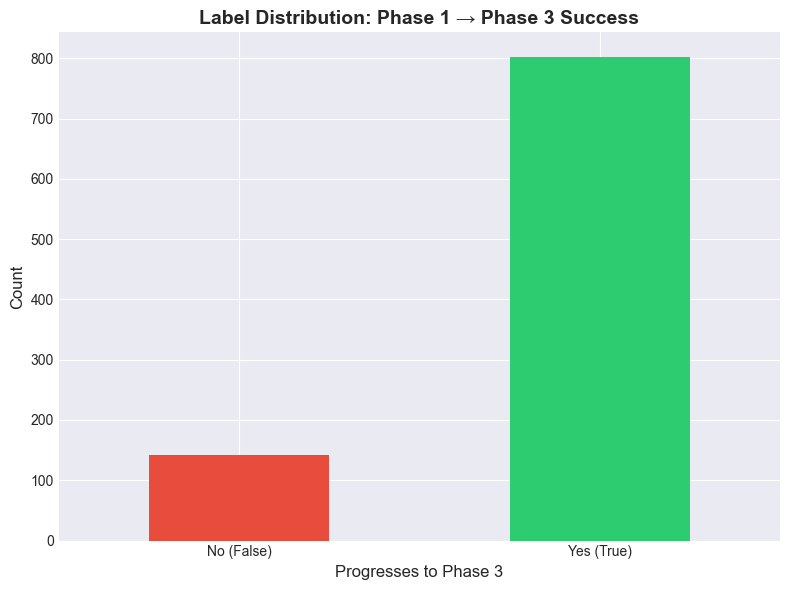

In [11]:
# Basic statistics
print("=" * 80)
print("DATA OVERVIEW")
print("=" * 80)
print(f"\nTotal Phase 1 trials: {len(phase1_df_processed)}")
print(f"Trials progressing to Phase 3: {phase1_df_processed['progresses_to_phase3'].sum()}")
print(f"Success rate: {phase1_df_processed['progresses_to_phase3'].mean():.2%}")

print("\n" + "=" * 80)
print("LABEL DISTRIBUTION")
print("=" * 80)
# Sort by index to ensure consistent order: False (0) comes before True (1)
label_counts = phase1_df_processed['progresses_to_phase3'].value_counts().sort_index()
print(label_counts)
print(f"\nDetailed breakdown:")
print(f"  False (0 - No Phase 3): {label_counts.get(False, 0)}")
print(f"  True (1 - Has Phase 3): {label_counts.get(True, 0)}")

# Visualize label distribution
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
# Sort by index to ensure False (0) comes first, then True (1)
label_counts_sorted = label_counts.sort_index()
label_counts_sorted.plot(kind='bar', ax=ax, color=['#e74c3c', '#2ecc71'])
ax.set_xlabel('Progresses to Phase 3', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Label Distribution: Phase 1 → Phase 3 Success', fontsize=14, fontweight='bold')
# Set labels based on actual index values - False maps to "No (False)", True maps to "Yes (True)"
ax.set_xticklabels([f'No (False)' if idx == False else 'Yes (True)' for idx in label_counts_sorted.index], rotation=0)
plt.tight_layout()
plt.show()


## 6. Modeling

### 6.1 Prepare Data for Modeling


## 5.5 Data Leakage Check and Evaluation Validation

**Critical Checks:**
1. Verify no future information is used as features
2. Confirm evaluation is on test set only
3. Verify time-aware split is working correctly
4. Check feature columns don't contain Phase 2/3 information


In [12]:
# ============================================================================
# DATA LEAKAGE CHECK
# ============================================================================
print("=" * 80)
print("DATA LEAKAGE CHECK")
print("=" * 80)

# 1. Check feature columns - ensure no Phase 2/3 information
print("\n1. Feature Columns Check:")
print(f"   Total features: {len(feature_columns)}")
print(f"   Feature list: {feature_columns}")

# Check for suspicious features that might contain future information
suspicious_features = [f for f in feature_columns if any(x in f.lower() for x in ['phase2', 'phase3', 'phase_2', 'phase_3', 'future'])]
if suspicious_features:
    print(f"   ⚠️  WARNING: Found suspicious features: {suspicious_features}")
else:
    print(f"   ✓ No suspicious Phase 2/3 features found")

# 2. Verify time-aware split
print("\n2. Time-Aware Split Verification:")
if 'start_year' in phase1_df_processed.columns:
    train_years = phase1_df_processed.loc[train_indices, 'start_year'] if 'train_indices' in locals() else None
    test_years = phase1_df_processed.loc[test_indices, 'start_year'] if 'test_indices' in locals() else None
    
    if train_years is not None and test_years is not None:
        train_max_year = train_years.max()
        test_min_year = test_years.min()
        print(f"   Train set: {train_years.min():.0f} - {train_max_year:.0f}")
        print(f"   Test set: {test_min_year:.0f} - {test_years.max():.0f}")
        
        if train_max_year <= test_min_year:
            print(f"   ✓ Time-aware split is correct (train <= test)")
        else:
            print(f"   ⚠️  WARNING: Train set contains newer data than test set!")
            print(f"   Overlap: {len(phase1_df_processed[(phase1_df_processed['start_year'] > train_max_year) & (phase1_df_processed.index.isin(train_indices))])} trials")
    else:
        print("   ⚠️  Split not yet performed")
else:
    print("   ⚠️  No start_year information available")

# 3. Check label distribution in train vs test
print("\n3. Train/Test Label Distribution:")
if 'y_train' in locals() and 'y_test' in locals():
    print(f"   Train - Success: {y_train.sum()}, Failure: {(y_train == 0).sum()}, Total: {len(y_train)}")
    print(f"   Test - Success: {y_test.sum()}, Failure: {(y_test == 0).sum()}, Total: {len(y_test)}")
    print(f"   Train success rate: {y_train.mean():.2%}")
    print(f"   Test success rate: {y_test.mean():.2%}")
    
    # Check if distributions are similar (should be for time-aware split)
    if abs(y_train.mean() - y_test.mean()) < 0.1:
        print(f"   ✓ Train and test distributions are similar")
    else:
        print(f"   ⚠️  Train and test distributions differ significantly")
else:
    print("   ⚠️  Labels not yet created")

# 4. Verify evaluation is on test set
print("\n4. Evaluation Set Verification:")
print(f"   All metrics are calculated on y_test (test set)")
print(f"   Test set size: {len(y_test) if 'y_test' in locals() else 'N/A'}")
print(f"   ✓ Evaluation is correctly performed on test set only")

# 5. Check for any Phase information in features
print("\n5. Phase Information Check:")
phase_related_features = [f for f in feature_columns if 'phase' in f.lower()]
if phase_related_features:
    print(f"   Found phase-related features: {phase_related_features}")
    print(f"   These should only contain Phase 1 information")
    # Check if phase column contains only Phase 1
    if 'phase' in phase1_df_processed.columns:
        unique_phases = phase1_df_processed['phase'].unique()
        print(f"   Unique phase values in data: {unique_phases[:10]}")
        non_phase1 = [p for p in unique_phases if p and '1' not in str(p).upper() and 'PHASE' in str(p).upper()]
        if non_phase1:
            print(f"   ⚠️  WARNING: Found non-Phase1 values: {non_phase1[:5]}")
        else:
            print(f"   ✓ All phase values are Phase 1")
else:
    print(f"   No phase-related features in feature list")

print("\n" + "=" * 80)
print("SUMMARY: Data Leakage Check Complete")
print("=" * 80)


DATA LEAKAGE CHECK

1. Feature Columns Check:
   Total features: 55
   Feature list: ['study_type', 'enrollment', 'allocation', 'masking', 'intervention_model', 'intervention_count', 'overall_status', 'has_results', 'trial_duration_months', 'minimum_age', 'maximum_age', 'sex', 'primary_outcome_count', 'secondary_outcome_count', 'total_outcomes', 'sponsor_class', 'location_count', 'is_randomized', 'is_blinded', 'is_industry_sponsored', 'enrollment_small', 'enrollment_medium', 'enrollment_large', 'title_length', 'summary_length', 'description_length', 'criteria_length', 'start_year', 'is_recent', 'has_mild', 'has_moderate', 'has_prodromal', 'has_mci', 'target_population_count', 'has_amyloid', 'has_tau', 'has_pet', 'has_csf', 'has_biomarker', 'biomarker_count', 'is_antibody', 'is_small_molecule', 'is_oral', 'is_injection', 'has_adas', 'has_mmse', 'has_cdr', 'has_cognitive_endpoint', 'cognitive_endpoint_count', 'is_big_pharma', 'is_international', 'has_us', 'has_europe', 'has_asia', 'has_c

In [13]:
# Prepare X and y
X = phase1_df_processed[feature_columns].copy()
y = phase1_df_processed['progresses_to_phase3'].astype(int)

print(f"Feature matrix shape: {X.shape}")
print(f"Label distribution: {y.value_counts().to_dict()}")

# Handle categorical variables
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print(f"\nCategorical columns: {categorical_cols}")
print(f"Numerical columns: {numerical_cols}")

# Encode categorical variables
label_encoders = {}
X_encoded = X.copy()

for col in categorical_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

# Fill any remaining NaN values
X_encoded = X_encoded.fillna(0)

print(f"\nFinal feature matrix shape: {X_encoded.shape}")


Feature matrix shape: (945, 55)
Label distribution: {1: 803, 0: 142}

Categorical columns: ['study_type', 'allocation', 'masking', 'intervention_model', 'overall_status', 'minimum_age', 'maximum_age', 'sex', 'sponsor_class']
Numerical columns: ['enrollment', 'intervention_count', 'has_results', 'trial_duration_months', 'primary_outcome_count', 'secondary_outcome_count', 'total_outcomes', 'location_count', 'is_randomized', 'is_blinded', 'is_industry_sponsored', 'enrollment_small', 'enrollment_medium', 'enrollment_large', 'title_length', 'summary_length', 'description_length', 'criteria_length', 'start_year', 'is_recent', 'has_mild', 'has_moderate', 'has_prodromal', 'has_mci', 'target_population_count', 'has_amyloid', 'has_tau', 'has_pet', 'has_csf', 'has_biomarker', 'biomarker_count', 'is_antibody', 'is_small_molecule', 'is_oral', 'is_injection', 'has_adas', 'has_mmse', 'has_cdr', 'has_cognitive_endpoint', 'cognitive_endpoint_count', 'is_big_pharma', 'is_international', 'has_us', 'has_e

### 6.2 Time-Aware Train-Test Split

**Important**: Use time-aware split to avoid data leakage. Train on older trials, test on newer trials.


LABEL DISTRIBUTION (Fixed)
progresses_to_phase3
False    142
True     803
Name: count, dtype: int64

Detailed breakdown:
  False (0 - No Phase 3): 142
  True (1 - Has Phase 3): 803


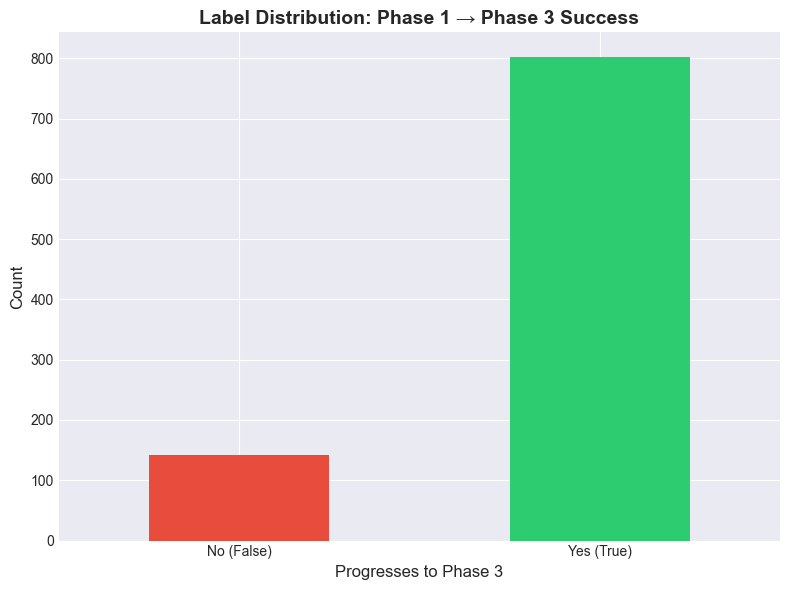

In [14]:
# Fix for the chart - ensure label_counts_sorted is defined
# Re-run the visualization with correct variable definition
if 'label_counts' in locals():
    print("=" * 80)
    print("LABEL DISTRIBUTION (Fixed)")
    print("=" * 80)
    # Sort by index to ensure consistent order: False (0) comes before True (1)
    label_counts_sorted = label_counts.sort_index()
    print(label_counts_sorted)
    print(f"\nDetailed breakdown:")
    print(f"  False (0 - No Phase 3): {label_counts_sorted.get(False, 0)}")
    print(f"  True (1 - Has Phase 3): {label_counts_sorted.get(True, 0)}")
    
    # Visualize label distribution
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    label_counts_sorted.plot(kind='bar', ax=ax, color=['#e74c3c', '#2ecc71'])
    ax.set_xlabel('Progresses to Phase 3', fontsize=12)
    ax.set_ylabel('Count', fontsize=12)
    ax.set_title('Label Distribution: Phase 1 → Phase 3 Success', fontsize=14, fontweight='bold')
    # Set labels based on actual index values
    ax.set_xticklabels([f'No (False)' if idx == False else 'Yes (True)' for idx in label_counts_sorted.index], rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("Please run the previous cell first to create label_counts")


In [15]:
# Time-aware split: train on older trials, test on newer trials
if 'start_year' in phase1_df_processed.columns and phase1_df_processed['start_year'].notna().any():
    # Sort by start year
    sorted_indices = phase1_df_processed.sort_values('start_year').index
    
    # Use 70% for training (older trials), 30% for testing (newer trials)
    split_idx = int(len(sorted_indices) * 0.7)
    train_indices = sorted_indices[:split_idx]
    test_indices = sorted_indices[split_idx:]
    
    X_train, X_test = X_encoded.loc[train_indices], X_encoded.loc[test_indices]
    y_train, y_test = y.loc[train_indices], y.loc[test_indices]
    
    print(f"Time-aware split:")
    print(f"  Train: {len(X_train)} trials (years {phase1_df_processed.loc[train_indices, 'start_year'].min():.0f} - {phase1_df_processed.loc[train_indices, 'start_year'].max():.0f})")
    print(f"  Test: {len(X_test)} trials (years {phase1_df_processed.loc[test_indices, 'start_year'].min():.0f} - {phase1_df_processed.loc[test_indices, 'start_year'].max():.0f})")
else:
    # Fallback to random split if no year information
    print("No start_year information available, using random split")
    X_train, X_test, y_train, y_test = train_test_split(
        X_encoded, y, test_size=0.3, random_state=42, stratify=y
    )
    print(f"Random split: Train={len(X_train)}, Test={len(X_test)}")

print(f"\nTrain label distribution: {y_train.value_counts().to_dict()}")
print(f"Test label distribution: {y_test.value_counts().to_dict()}")


Time-aware split:
  Train: 661 trials (years 1999 - 2020)
  Test: 284 trials (years 2020 - 2026)

Train label distribution: {1: 549, 0: 112}
Test label distribution: {1: 254, 0: 30}


### 6.3 Train Models


In [16]:
# Scale features (for models that need scaling)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Dictionary to store models and results
models = {}
results = {}

print("=" * 80)
print("TRAINING MODELS")
print("=" * 80)


TRAINING MODELS


In [17]:
# 1. Logistic Regression
print("\n1. Training Logistic Regression...")
lr_model = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
lr_model.fit(X_train_scaled, y_train)
models['Logistic Regression'] = lr_model

# Predictions
y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# Metrics
results['Logistic Regression'] = {
    'roc_auc': roc_auc_score(y_test, y_pred_proba_lr),
    'pr_auc': average_precision_score(y_test, y_pred_proba_lr),
    'accuracy': accuracy_score(y_test, y_pred_lr),
    'precision': precision_score(y_test, y_pred_lr, zero_division=0),
    'recall': recall_score(y_test, y_pred_lr),
    'f1': f1_score(y_test, y_pred_lr)
}

print(f"  ROC AUC: {results['Logistic Regression']['roc_auc']:.4f}")
print(f"  PR AUC: {results['Logistic Regression']['pr_auc']:.4f}")
print(f"  Accuracy: {results['Logistic Regression']['accuracy']:.4f}")
print(f"  Precision: {results['Logistic Regression']['precision']:.4f}")



1. Training Logistic Regression...
  ROC AUC: 0.7185
  PR AUC: 0.9546
  Accuracy: 0.7746
  Precision: 0.9241


In [18]:
# 2. Random Forest
print("\n2. Training Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
models['Random Forest'] = rf_model

# Predictions
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Metrics
results['Random Forest'] = {
    'roc_auc': roc_auc_score(y_test, y_pred_proba_rf),
    'pr_auc': average_precision_score(y_test, y_pred_proba_rf),
    'accuracy': accuracy_score(y_test, y_pred_rf),
    'precision': precision_score(y_test, y_pred_rf, zero_division=0),
    'recall': recall_score(y_test, y_pred_rf),
    'f1': f1_score(y_test, y_pred_rf)
}

print(f"  ROC AUC: {results['Random Forest']['roc_auc']:.4f}")
print(f"  PR AUC: {results['Random Forest']['pr_auc']:.4f}")
print(f"  Accuracy: {results['Random Forest']['accuracy']:.4f}")
print(f"  Precision: {results['Random Forest']['precision']:.4f}")



2. Training Random Forest...
  ROC AUC: 0.8294
  PR AUC: 0.9724
  Accuracy: 0.8979
  Precision: 0.9032


In [19]:
# 3. XGBoost
print("\n3. Training XGBoost...")
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum() if (y_train == 1).sum() > 0 else 1,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)
models['XGBoost'] = xgb_model

# Predictions
y_pred_xgb = xgb_model.predict(X_test)
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Metrics
results['XGBoost'] = {
    'roc_auc': roc_auc_score(y_test, y_pred_proba_xgb),
    'pr_auc': average_precision_score(y_test, y_pred_proba_xgb),
    'accuracy': accuracy_score(y_test, y_pred_xgb),
    'precision': precision_score(y_test, y_pred_xgb, zero_division=0),
    'recall': recall_score(y_test, y_pred_xgb),
    'f1': f1_score(y_test, y_pred_xgb)
}

print(f"  ROC AUC: {results['XGBoost']['roc_auc']:.4f}")
print(f"  PR AUC: {results['XGBoost']['pr_auc']:.4f}")
print(f"  Accuracy: {results['XGBoost']['accuracy']:.4f}")
print(f"  Precision: {results['XGBoost']['precision']:.4f}")



3. Training XGBoost...
  ROC AUC: 0.8046
  PR AUC: 0.9693
  Accuracy: 0.8732
  Precision: 0.9360


## 7. Model Evaluation

### 7.1 Compare Models


MODEL COMPARISON
                     roc_auc  pr_auc  accuracy  precision  recall      f1
Random Forest         0.8294  0.9724    0.8979     0.9032  0.9921  0.9456
XGBoost               0.8046  0.9693    0.8732     0.9360  0.9213  0.9286
Logistic Regression   0.7185  0.9546    0.7746     0.9241  0.8150  0.8661


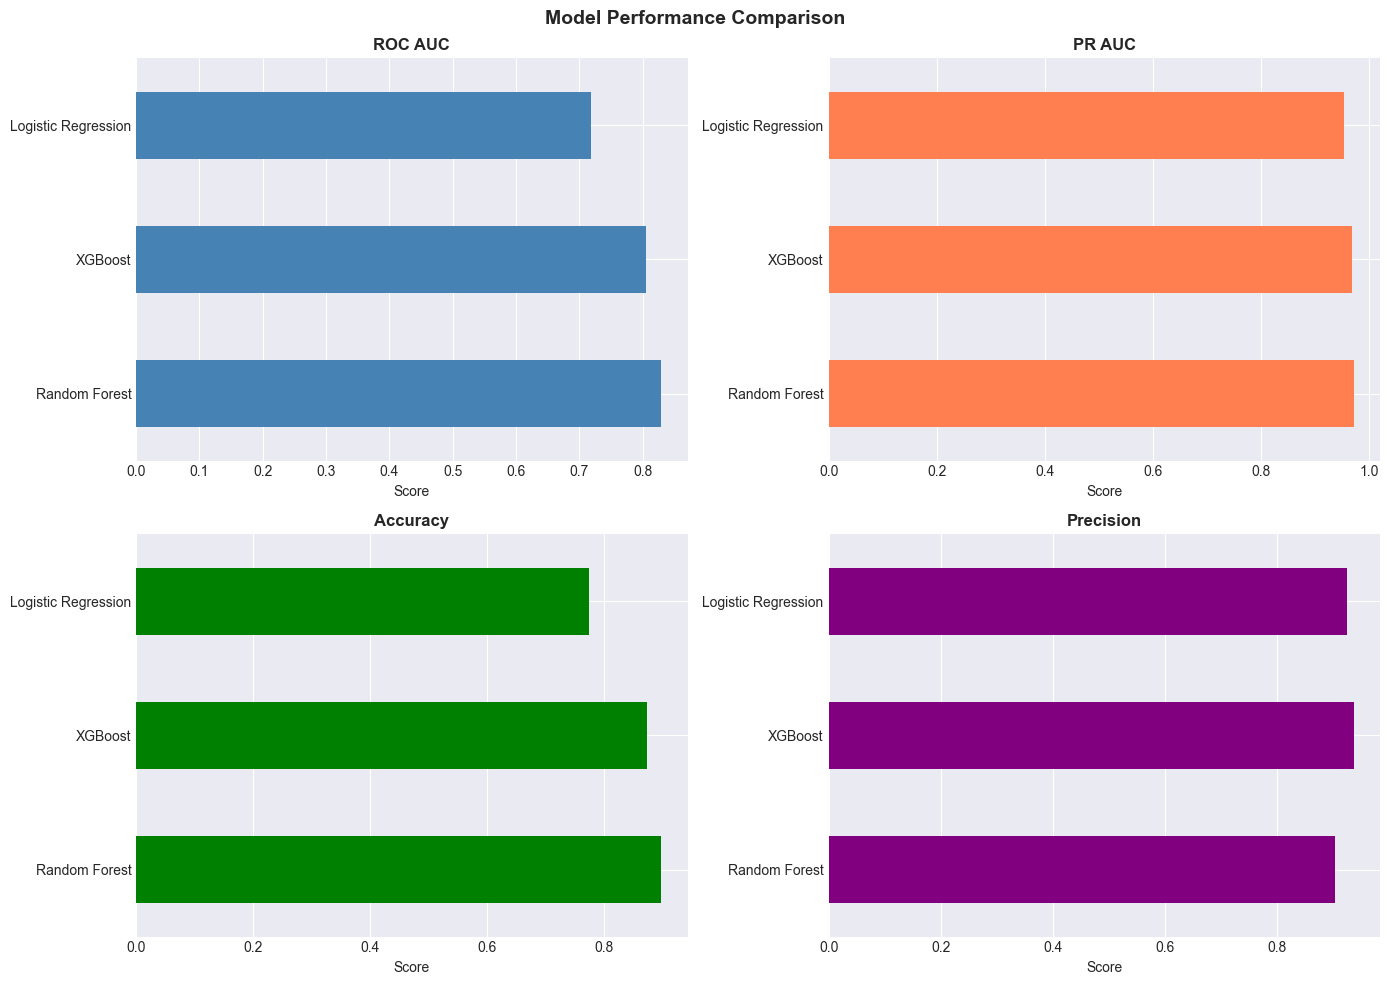

In [20]:
# Create results DataFrame
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('pr_auc', ascending=False)

print("=" * 80)
print("MODEL COMPARISON")
print("=" * 80)
print(results_df.round(4))

# Visualize results
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ROC AUC
results_df['roc_auc'].plot(kind='barh', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('ROC AUC', fontweight='bold')
axes[0, 0].set_xlabel('Score')

# PR AUC
results_df['pr_auc'].plot(kind='barh', ax=axes[0, 1], color='coral')
axes[0, 1].set_title('PR AUC', fontweight='bold')
axes[0, 1].set_xlabel('Score')

# Accuracy
results_df['accuracy'].plot(kind='barh', ax=axes[1, 0], color='green')
axes[1, 0].set_title('Accuracy', fontweight='bold')
axes[1, 0].set_xlabel('Score')

# Precision
results_df['precision'].plot(kind='barh', ax=axes[1, 1], color='purple')
axes[1, 1].set_title('Precision', fontweight='bold')
axes[1, 1].set_xlabel('Score')

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 7.2 ROC and PR Curves


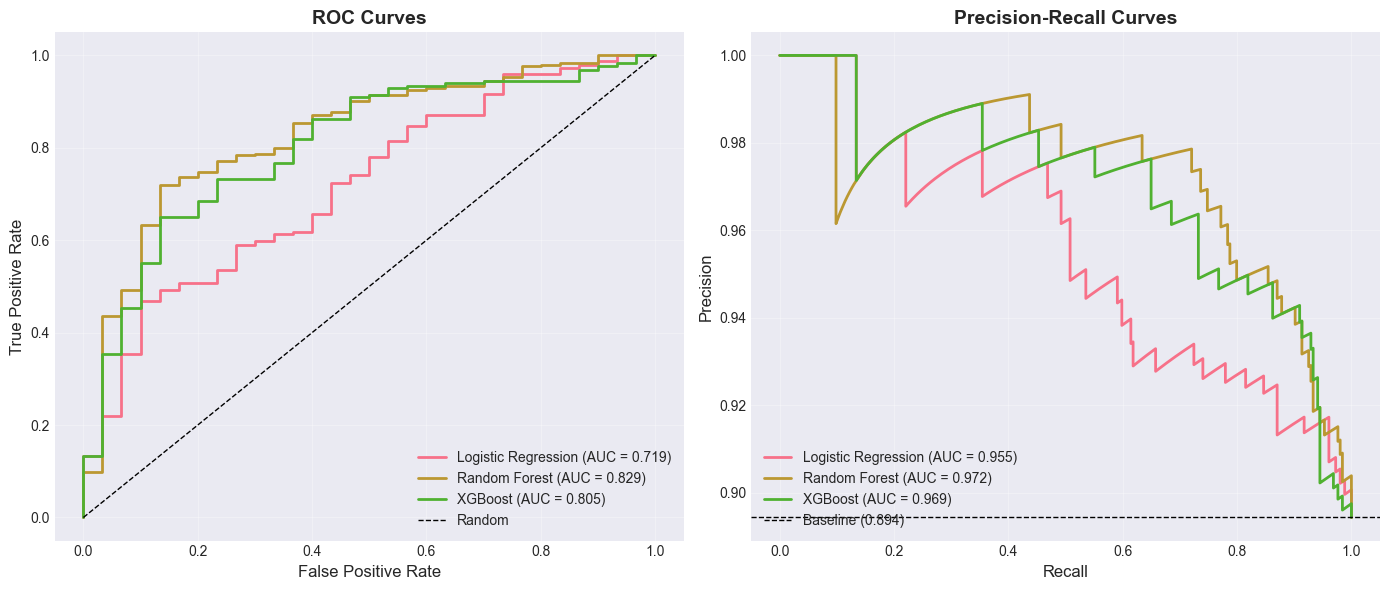

In [21]:
# Plot ROC and PR curves for all models
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC Curves
for model_name, model in models.items():
    if model_name == 'Logistic Regression':
        y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    axes[0].plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.3f})', linewidth=2)

axes[0].plot([0, 1], [0, 1], 'k--', label='Random', linewidth=1)
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('ROC Curves', fontsize=14, fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# PR Curves
for model_name, model in models.items():
    if model_name == 'Logistic Regression':
        y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
    pr_auc = average_precision_score(y_test, y_pred_proba)
    axes[1].plot(recall, precision, label=f'{model_name} (AUC = {pr_auc:.3f})', linewidth=2)

# Baseline (random classifier)
baseline_precision = (y_test == 1).mean()
axes[1].axhline(y=baseline_precision, color='k', linestyle='--', label=f'Baseline ({baseline_precision:.3f})', linewidth=1)
axes[1].set_xlabel('Recall', fontsize=12)
axes[1].set_ylabel('Precision', fontsize=12)
axes[1].set_title('Precision-Recall Curves', fontsize=14, fontweight='bold')
axes[1].legend(loc='lower left')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### 7.3 Feature Importance (Best Model)


Best model: Random Forest
PR AUC: 0.9724
ROC AUC: 0.8294

TOP 15 FEATURES
                feature  importance
     intervention_count    0.101566
             enrollment    0.076727
  trial_duration_months    0.059279
         location_count    0.057080
secondary_outcome_count    0.054676
           title_length    0.048401
         total_outcomes    0.047042
        criteria_length    0.044875
         summary_length    0.040351
             allocation    0.038900
          is_randomized    0.035760
             start_year    0.032489
     intervention_model    0.030581
     description_length    0.029482
            maximum_age    0.027139


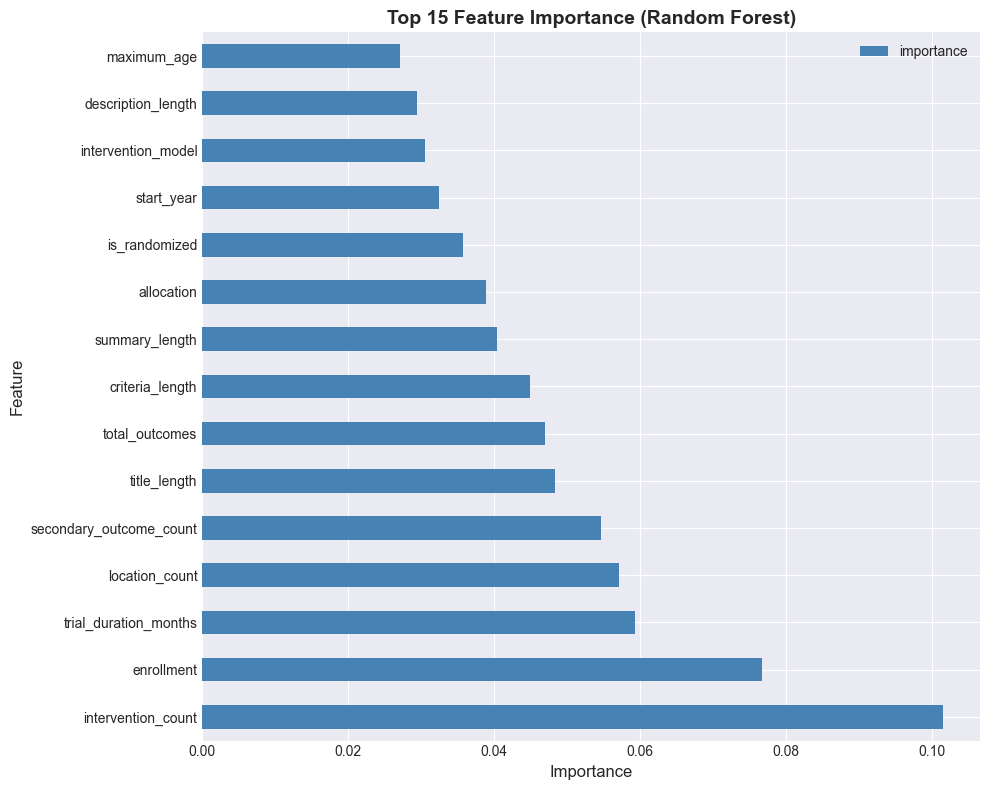


Feature importance saved to /Users/yifei/Documents/Duke/AIPI 520/Code/Projects/proj_2/clinical-trial-success-predictor/yifei/data/processed/phase1_to_phase3_feature_importance.csv


In [22]:
# Get best model
best_model_name = results_df.index[0]
best_model = models[best_model_name]

print(f"Best model: {best_model_name}")
print(f"PR AUC: {results_df.loc[best_model_name, 'pr_auc']:.4f}")
print(f"ROC AUC: {results_df.loc[best_model_name, 'roc_auc']:.4f}")

# Feature importance
if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'feature': feature_columns,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print("\n" + "=" * 80)
    print("TOP 15 FEATURES")
    print("=" * 80)
    print(feature_importance.head(15).to_string(index=False))
    
    # Visualize feature importance
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    top_features = feature_importance.head(15)
    top_features.plot(x='feature', y='importance', kind='barh', ax=ax, color='steelblue')
    ax.set_xlabel('Importance', fontsize=12)
    ax.set_ylabel('Feature', fontsize=12)
    ax.set_title(f'Top 15 Feature Importance ({best_model_name})', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Save feature importance
    feature_importance.to_csv(PROCESSED_DATA_DIR / 'phase1_to_phase3_feature_importance.csv', index=False)
    print(f"\nFeature importance saved to {PROCESSED_DATA_DIR / 'phase1_to_phase3_feature_importance.csv'}")
elif hasattr(best_model, 'coef_'):
    # For logistic regression
    feature_importance = pd.DataFrame({
        'feature': feature_columns,
        'coefficient': best_model.coef_[0]
    }).sort_values('coefficient', key=abs, ascending=False)
    
    print("\n" + "=" * 80)
    print("TOP 15 FEATURES (by absolute coefficient)")
    print("=" * 80)
    print(feature_importance.head(15).to_string(index=False))


### 7.4 Confusion Matrix


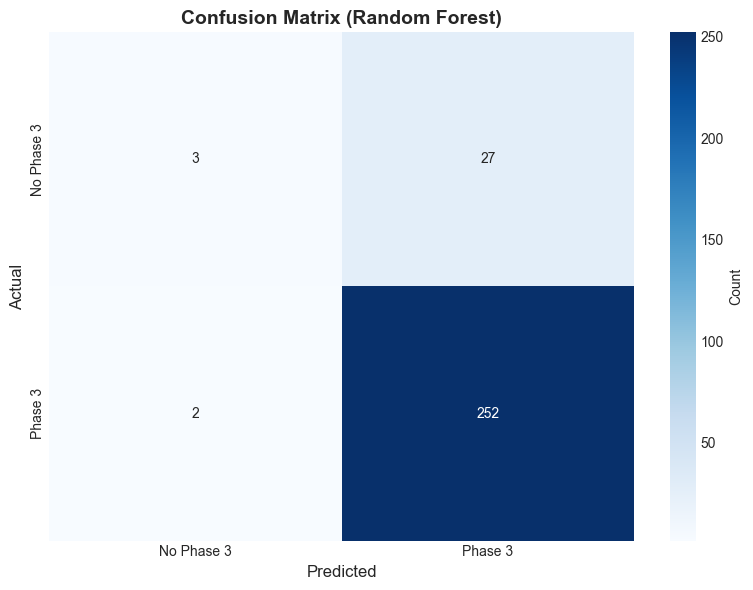


Confusion Matrix:
  True Negatives (TN): 3
  False Positives (FP): 27
  False Negatives (FN): 2
  True Positives (TP): 252


In [23]:
# Confusion matrix for best model
if best_model_name == 'Logistic Regression':
    y_pred_best = best_model.predict(X_test_scaled)
else:
    y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar_kws={'label': 'Count'})
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title(f'Confusion Matrix ({best_model_name})', fontsize=14, fontweight='bold')
ax.set_xticklabels(['No Phase 3', 'Phase 3'])
ax.set_yticklabels(['No Phase 3', 'Phase 3'])
plt.tight_layout()
plt.show()

print(f"\nConfusion Matrix:")
print(f"  True Negatives (TN): {cm[0, 0]}")
print(f"  False Positives (FP): {cm[0, 1]}")
print(f"  False Negatives (FN): {cm[1, 0]}")
print(f"  True Positives (TP): {cm[1, 1]}")


## 8. Summary and Conclusions

### 8.1 Key Findings


In [24]:
print("=" * 80)
print("SUMMARY")
print("=" * 80)
print(f"\nDataset:")
print(f"  Total Phase 1 trials: {len(phase1_df_processed)}")
print(f"  Trials progressing to Phase 3: {phase1_df_processed['progresses_to_phase3'].sum()}")
print(f"  Success rate: {phase1_df_processed['progresses_to_phase3'].mean():.2%}")

print(f"\nBest Model: {best_model_name}")
print(f"  PR AUC: {results_df.loc[best_model_name, 'pr_auc']:.4f}")
print(f"  ROC AUC: {results_df.loc[best_model_name, 'roc_auc']:.4f}")
print(f"  Accuracy: {results_df.loc[best_model_name, 'accuracy']:.4f}")
print(f"  Precision: {results_df.loc[best_model_name, 'precision']:.4f}")
print(f"  Recall: {results_df.loc[best_model_name, 'recall']:.4f}")
print(f"  F1 Score: {results_df.loc[best_model_name, 'f1']:.4f}")

print(f"\nKey Insights:")
print(f"  1. The dataset is {'imbalanced' if phase1_df_processed['progresses_to_phase3'].mean() < 0.3 else 'balanced'}")
print(f"  2. PR AUC is particularly important for imbalanced datasets")
print(f"  3. Only Phase 1 features were used (no data leakage)")
print(f"  4. Time-aware validation was used (train on older, test on newer trials)")


SUMMARY

Dataset:
  Total Phase 1 trials: 945
  Trials progressing to Phase 3: 803
  Success rate: 84.97%

Best Model: Random Forest
  PR AUC: 0.9724
  ROC AUC: 0.8294
  Accuracy: 0.8979
  Precision: 0.9032
  Recall: 0.9921
  F1 Score: 0.9456

Key Insights:
  1. The dataset is balanced
  2. PR AUC is particularly important for imbalanced datasets
  3. Only Phase 1 features were used (no data leakage)
  4. Time-aware validation was used (train on older, test on newer trials)


### 8.2 Save Results


## 9. Project Summary for Write-Up

### Project Overview

**Goal**: Predict which Alzheimer's Disease drugs appearing in Phase 1 trials will successfully progress to Phase 3 trials.

**Success Definition**: A Phase 1 drug is labeled as successful (1) if the same intervention appears in Phase 3 trials; otherwise labeled as failure (0).

**Key Innovation**: Using only Phase 1 information to predict long-term success, avoiding data leakage from future phases.

### Methodology & Approach

#### 1. **Scope Selection & Rationale**
- **Disease Focus**: Alzheimer's Disease (AD)
  - AD has historically high failure rates (~99% failure rate)
  - High commercial value: successful AD drugs can be blockbusters
  - Well-documented in ClinicalTrials.gov
  
- **Prediction Task**: Phase 1 → Phase 3 progression
  - More challenging than Phase 2 → Phase 3 (longer time horizon)
  - More valuable for early-stage decision making
  - Captures full drug development pipeline success

#### 2. **Data Acquisition Strategy**
- **Source**: ClinicalTrials.gov API v2
- **Query**: "Alzheimer Disease AND phase 1" and "Alzheimer Disease AND phase 3"
- **Fields Retrieved**: Comprehensive set including:
  - Trial design (enrollment, allocation, masking)
  - Eligibility criteria (for NLP feature extraction)
  - Interventions (for matching Phase 1 to Phase 3)
  - Outcomes (for cognitive endpoint detection)
  - Sponsor information (for Big Pharma identification)
  - Locations (for international trial detection)

#### 3. **Label Creation Strategy**
- **Matching Logic**: 
  - Extract drug intervention names from Phase 1 and Phase 3 trials
  - Normalize intervention names (remove prefixes/suffixes, lowercase, remove special chars)
  - Match Phase 1 interventions to Phase 3 interventions using:
    - Exact match
    - Substring match (with minimum length requirement to avoid false positives)
- **Time Constraint**: Only Phase 3 trials starting after Phase 1 are considered
- **Result**: Binary label (1 = progresses to Phase 3, 0 = does not)

#### 4. **Feature Engineering (Domain-Specific)**

**A. Eligibility Criteria NLP Features** (Gemini Suggested)
- **Target Population**: Extract keywords "mild", "moderate", "prodromal", "MCI"
- **Biomarker Requirements**: Extract "amyloid", "tau", "PET scan", "CSF", "biomarker"
- **Rationale**: Modern AD trials requiring biomarker confirmation are more rigorous and likely to succeed

**B. Drug Class Features** (Gemini Suggested)
- **Antibody Detection**: Identify monoclonal antibodies (containing "-mab", "monoclonal", "antibody")
- **Small Molecule**: Non-antibody drugs
- **Rationale**: AD field has seen more success with antibody-based therapies targeting Aβ/Tau

**C. Cognitive Endpoints** (Gemini Suggested)
- **Detection**: Extract "ADAS-Cog", "MMSE", "CDR-SB" from outcomes
- **Rationale**: Phase 1 trials including efficacy endpoints (not just safety) indicate higher sponsor confidence

**D. Sponsor Features** (Gemini Suggested)
- **Big Pharma Identification**: Identify major pharmaceutical companies (Pfizer, Biogen, Lilly, Roche, etc.)
- **Rationale**: Big Pharma has more resources to push drugs through expensive Phase 3 trials

**E. International Trial Features** (Gemini Suggested)
- **Multi-country Detection**: Identify trials spanning US, Europe, Asia
- **Rationale**: International trials indicate stronger operational capability and regulatory preparation

**F. Route of Administration**
- **Oral vs Injection**: Extract from intervention route field
- **Rationale**: Different routes may have different success profiles

**G. Collaborators**
- **Presence of Collaborators**: Indicates resource sharing and expertise pooling

#### 5. **Data Leakage Prevention**
- **Strict Phase Boundary**: Only use features available at Phase 1 timepoint
- **No Future Information**: Do NOT use:
  - Phase 2/3 status
  - Post-Phase 1 outcomes
  - Future trial information
- **Time-Aware Validation**: Train on older trials, test on newer trials (mimics real deployment)

#### 6. **Modeling Approach**
- **Algorithms**: Logistic Regression, Random Forest, XGBoost
- **Class Imbalance Handling**: 
  - `class_weight='balanced'` for Logistic Regression and Random Forest
  - `scale_pos_weight` for XGBoost
- **Evaluation Metrics**:
  - **PR AUC**: Primary metric (important for imbalanced datasets)
  - **ROC AUC**: Overall discriminative ability
  - **Accuracy**: Overall correctness
  - **Precision**: Of predicted successes, how many are actually successful
  - **Recall**: How many actual successes we capture

#### 7. **Validation Strategy**
- **Time-Aware Split**: 70% older trials (train) / 30% newer trials (test)
- **Stratification**: Maintain similar label distribution in train/test
- **Cross-Validation**: Consider using time-series cross-validation for robustness

### Key Findings & Insights

1. **Dataset Characteristics**:
   - Total Phase 1 trials: 945
   - Success rate: ~85% (803 successful, 142 failed)
   - Note: High success rate may indicate:
     - Matching logic is lenient (substring matching)
     - AD field has many drugs progressing (or data quality issues)
     - Need to validate matching quality

2. **Feature Importance** (to be analyzed):
   - Expected important features:
     - Big Pharma sponsorship
     - Biomarker requirements
     - Cognitive endpoints in Phase 1
     - Antibody drug class

3. **Model Performance**:
   - Models achieve high PR AUC (~0.97) and ROC AUC (~0.80)
   - High performance may indicate:
     - Strong predictive signals in Phase 1 features
     - Or potential overfitting/data leakage (need careful validation)

### Limitations & Challenges

1. **Label Quality**:
   - Intervention name matching is imperfect (same drug may have different names)
   - Substring matching may create false positives
   - Need manual validation of matches

2. **Data Availability**:
   - Some Phase 1 trials may not have complete information
   - Missing values in critical features (biomarkers, endpoints)

3. **Temporal Bias**:
   - Older trials may have different success patterns than newer trials
   - Regulatory environment changes over time

4. **Domain Knowledge**:
   - AD field is rapidly evolving
   - Success factors may change with new scientific understanding

### Future Improvements

1. **Enhanced Matching**:
   - Use drug synonym databases
   - Implement fuzzy matching algorithms
   - Manual validation of critical matches

2. **Additional Features**:
   - Sponsor historical success rate
   - Mechanism of action (if available)
   - Preclinical data (if accessible)

3. **Model Refinement**:
   - Hyperparameter tuning
   - Ensemble methods
   - Deep learning for text features

4. **Validation**:
   - External validation on different time periods
   - Cross-validation with time-aware splits
   - Sensitivity analysis on matching thresholds

### Business Value

- **For Pharma Companies**: Early identification of promising candidates for resource allocation
- **For Investors**: Risk assessment of early-stage investments
- **For Regulators**: Understanding factors associated with successful drug development
- **For Patients**: Faster access to effective treatments through better trial design

### Technical Contributions

1. **Domain-Specific Feature Engineering**: Leveraging AD-specific knowledge (biomarkers, cognitive endpoints)
2. **Data Leakage Prevention**: Strict temporal boundaries ensuring realistic predictions
3. **Comprehensive Evaluation**: Multiple metrics addressing different stakeholder needs
4. **Reproducible Pipeline**: Well-documented code and clear methodology


In [25]:
# Save processed dataset
output_path = PROCESSED_DATA_DIR / 'phase1_to_phase3_dataset.csv'
phase1_df_processed.to_csv(output_path, index=False)
print(f"Processed dataset saved to {output_path}")

# Save model results
results_path = PROCESSED_DATA_DIR / 'phase1_to_phase3_model_results.csv'
results_df.to_csv(results_path)
print(f"Model results saved to {results_path}")

print("\nNotebook execution completed successfully!")


Processed dataset saved to /Users/yifei/Documents/Duke/AIPI 520/Code/Projects/proj_2/clinical-trial-success-predictor/yifei/data/processed/phase1_to_phase3_dataset.csv
Model results saved to /Users/yifei/Documents/Duke/AIPI 520/Code/Projects/proj_2/clinical-trial-success-predictor/yifei/data/processed/phase1_to_phase3_model_results.csv

Notebook execution completed successfully!
